# Preparation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import myo
import myoktros
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


# global variables
aggregate_all = False
arm_dominance = "right"
assets_path = Path.cwd() / "assets"
config_path = Path.cwd() / "config.ini"
data_path = Path.cwd() / "data"
emg_mode = myo.types.EMGMode.SEND_FILT
n_samples = 50
knn_k = 3
knn_algorithm = "auto"
knn_metric = "minkowski"
svm_c = 1.0
svm_degree = 3
svm_gamma = "scale"
svm_kernel = "linear"

user = 'iomz'
test_size = 0.7

# configurations
myoktros.Gesture.load_config(config_path)

# options
np.set_printoptions(precision=3, suppress=True)
print(myoktros.Gesture.names)

['rest', 'grab', 'push', 'rake', 'horn', 'shoot']


In [2]:
features = myoktros.GestureModel.read_data(data_path, aggregate_all, arm_dominance, emg_mode, n_samples, user)
labels = features.pop('gesture')

x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=test_size)
print(len(y_train), len(y_test))

395 924


# Train the models

## keras

In [3]:
ksm = myoktros.KerasSequentialModel.fit(
    x_train,
    x_test,
    y_train,
    y_test,
    aggregate_all,
    arm_dominance,
    assets_path,
    emg_mode,
    n_samples,
    user,
)

Epoch 1/1000
4/4 [==============================] - 0s 33ms/step - loss: 23.2929 - sparse_categorical_accuracy: 0.3494 - val_loss: 2.7027 - val_sparse_categorical_accuracy: 0.5465
Epoch 2/1000
4/4 [==============================] - 0s 7ms/step - loss: 4.7066 - sparse_categorical_accuracy: 0.4911 - val_loss: 1.8885 - val_sparse_categorical_accuracy: 0.7359
Epoch 3/1000
4/4 [==============================] - 0s 7ms/step - loss: 1.0405 - sparse_categorical_accuracy: 0.7316 - val_loss: 0.5015 - val_sparse_categorical_accuracy: 0.8626
Epoch 4/1000
4/4 [==============================] - 0s 6ms/step - loss: 0.6911 - sparse_categorical_accuracy: 0.8152 - val_loss: 0.8372 - val_sparse_categorical_accuracy: 0.8106
Epoch 5/1000
4/4 [==============================] - 0s 6ms/step - loss: 0.8536 - sparse_categorical_accuracy: 0.7595 - val_loss: 0.8856 - val_sparse_categorical_accuracy: 0.7132
Epoch 6/1000
4/4 [==============================] - 0s 6ms/step - loss: 0.6300 - sparse_categorical_accuracy

INFO:tensorflow:Assets written to: /Users/iomz/ghq/github.com/Interactions-HSG/MyoKTROS/assets/keras-right-send_filt-50-samples-iomz-model/assets


In [4]:
# load the model from file
ksm = myoktros.KerasSequentialModel(
    aggregate_all,
    arm_dominance,
    assets_path,
    emg_mode,
    n_samples,
    user,
).model

## knn

In [5]:
knn = myoktros.KNNClassifier.fit(
    x_train,
    x_test,
    y_train,
    y_test,
    aggregate_all,
    arm_dominance,
    assets_path,
    emg_mode,
    knn_k,
    knn_algorithm,
    knn_metric,
    n_samples,
    user,
)

In [6]:
# load the model from file
knn = myoktros.KNNClassifier(
    aggregate_all,
    arm_dominance,
    assets_path,
    emg_mode,
    knn_k,
    knn_metric,
    n_samples,
    user,
).model

## svm

In [7]:
svm = myoktros.SVMClassifier.fit(
    x_train,
    x_test,
    y_train,
    y_test,
    aggregate_all,
    arm_dominance,
    assets_path,
    emg_mode,
    n_samples,
    svm_c,
    svm_degree,
    svm_gamma,
    svm_kernel,
    user,
)

In [8]:
# load the model from file
svm = myoktros.SVMClassifier(
    aggregate_all,
    arm_dominance,
    assets_path,
    emg_mode,
    n_samples,
    svm_c,
    svm_degree,
    svm_gamma,
    svm_kernel,
    user,
).model

# Visualize the classification performance vs. test data

29/29 [==============================] - 0s 447us/step


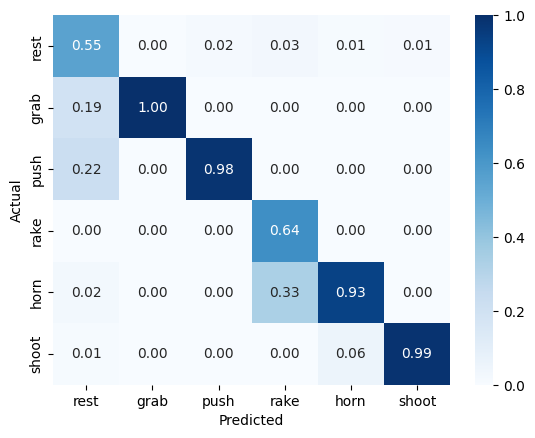

In [9]:
# keras
predictions = ksm.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, predicted_labels, normalize="pred")

# plot heatmap
ax = sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=myoktros.Gesture.names, yticklabels=myoktros.Gesture.names, fmt='.2f')
_ = ax.set(xlabel="Predicted", ylabel="Actual")
# _ = ax.xaxis.tick_top()

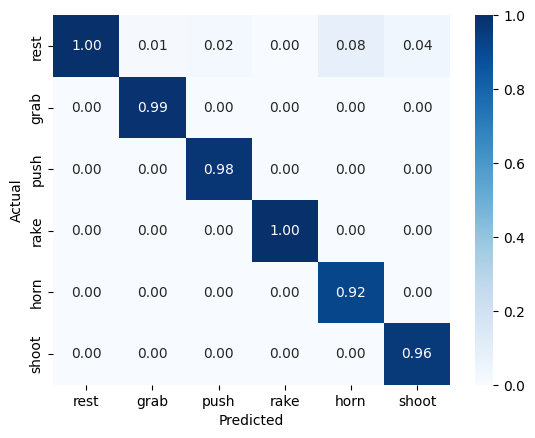

In [10]:
# knn
predicted_labels = knn.predict(x_test)
cm = confusion_matrix(y_test, predicted_labels, normalize="pred")

# plot heatmap
ax = sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=myoktros.Gesture.names, yticklabels=myoktros.Gesture.names, fmt='.2f')
_ = ax.set(xlabel="Predicted", ylabel="Actual")
# _ = ax.xaxis.tick_top()

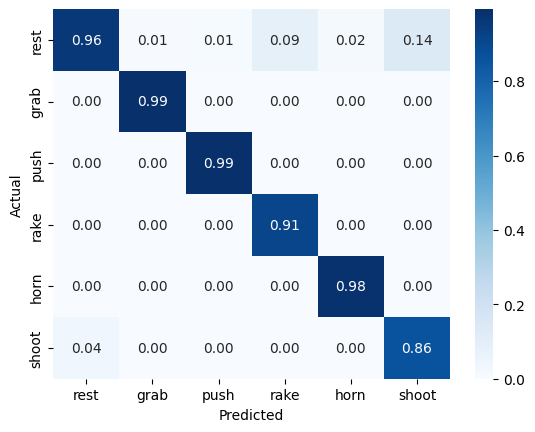

In [11]:
# svm
predicted_labels = svm.predict(x_test)
cm = confusion_matrix(y_test, predicted_labels, normalize="pred")

# plot heatmap
ax = sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=myoktros.Gesture.names, yticklabels=myoktros.Gesture.names, fmt='.2f')
_ = ax.set(xlabel="Predicted", ylabel="Actual")
# _ = ax.xaxis.tick_top()

# Batch finder

In [12]:
""" EXTRA_GESTURES = [
    "PUSH",
    "EXTENSION",
    "HORN",
    "FLEMING",
    "FLEXION",
]
# gesture combinations
gesture_combinations = []
for n in range(1, len(EXTRA_GESTURES)):
    for c in combinations(EXTRA_GESTURES, n):
        gesture_combinations.append(('REST', 'GRAB') + c) """

' EXTRA_GESTURES = [\n    "PUSH",\n    "EXTENSION",\n    "HORN",\n    "FLEMING",\n    "FLEXION",\n]\n# gesture combinations\ngesture_combinations = []\nfor n in range(1, len(EXTRA_GESTURES)):\n    for c in combinations(EXTRA_GESTURES, n):\n        gesture_combinations.append((\'REST\', \'GRAB\') + c) '

## Find out the optimal configurations for k-NN model

In [13]:
""" results = []
for i, c in enumerate(gesture_combinations):
    myoktros.Gesture.load_list(c)
    trials = []
    for knn_metric in ["minkowski", "euclidean", "manhattan"]:
        for k in range(1, 16, 2):
            for n_samples in range(25, 201, 25):
                # fit the model
                knn = myoktros.KNNClassifier.fit(
                    arm_dominance,
                    assets_path,
                    data_path,
                    emg_mode,
                    k,
                    knn_algorithm,
                    knn_metric,
                    n_samples,    
                )
                # get the appropriate test data
                x_test = myoktros.GestureModel.read_data(test_data_path, aggregate_all, arm_dominance, emg_mode, n_samples, user)
                y_test = x_test.pop('gesture')
                # evaluate the accuracy
                predicted_labels = knn.predict(x_test)
                acc = accuracy_score(y_test, predicted_labels)
                trials.append((k, knn_metric, n_samples, acc))
                results.append((c, k, knn_metric, n_samples, acc))

    best = max(trials, key=lambda r: r[3])
    print(f"[{i+1}/{len(gesture_combinations)}] {c} – k: {best[0]}, metric: {best[1]}, n_samples: {best[2]} at {best[3]:.3f}")

# sort the best performing combinations by the accuracy
results.sort(key=lambda r: r[4], reverse=True)

print("10 best performers:")
for i, r in enumerate(results[:10]):
    print(f"{i+1} {r[0]} – k: {r[1]}, metric: {r[2]}, n_samples: {r[3]}, at {r[4]}")

# write out the result to a csv file
now = time.strftime("%Y%m%d%H%M%S")
with (assets_path / f"eval-knn-{now}.csv").open('w') as f:
    print("gestures;k;metric;n_samples;acc", file=f)
    for r in results:
        print(";".join(map(str, (r[0], r[1], r[2], r[3], r[4]))), file=f) """

' results = []\nfor i, c in enumerate(gesture_combinations):\n    myoktros.Gesture.load_list(c)\n    trials = []\n    for knn_metric in ["minkowski", "euclidean", "manhattan"]:\n        for k in range(1, 16, 2):\n            for n_samples in range(25, 201, 25):\n                # fit the model\n                knn = myoktros.KNNClassifier.fit(\n                    arm_dominance,\n                    assets_path,\n                    data_path,\n                    emg_mode,\n                    k,\n                    knn_algorithm,\n                    knn_metric,\n                    n_samples,    \n                )\n                # get the appropriate test data\n                x_test = myoktros.GestureModel.read_data(test_data_path, aggregate_all, arm_dominance, emg_mode, n_samples, user)\n                y_test = x_test.pop(\'gesture\')\n                # evaluate the accuracy\n                predicted_labels = knn.predict(x_test)\n                acc = accuracy_score(y_test, 

## Find out the optimal configurations for SVM model

In [14]:
""" results = []
for i, c in enumerate(gesture_combinations):
    myoktros.Gesture.load_list(c)
    trials = []
    for svm_kernel in ["linear", "poly", "rbf", "sigmoid"]:
        for n_samples in range(25, 201, 25):
            # fit the model
            svm = myoktros.SVMClassifier.fit(
                arm_dominance,
                assets_path,
                data_path,
                emg_mode,
                n_samples,
                svm_c,
                svm_degree,
                svm_gamma,
                svm_kernel,
            )
            # get the appropriate test data
            x_test = myoktros.GestureModel.read_data(test_data_path, aggregate_all, arm_dominance, emg_mode, n_samples, user)
            y_test = x_test.pop('gesture')
            # evaluate the accuracy
            predicted_labels = svm.predict(x_test)
            acc = accuracy_score(y_test, predicted_labels)
            trials.append((acc, n_samples, svm_kernel))
            results.append((c, svm_c, svm_degree, svm_gamma, svm_kernel, n_samples, acc))
    
    best = max(trials, key=lambda r: r[0])
    print(f"[{i+1}/{len(gesture_combinations)}] {c} – acc: {best[0]:.3f} n_samples: {best[1]} kernel: {best[2]}")

# sort the best performing combinations by the accuracy
results.sort(key=lambda r: r[6], reverse=True)

# write out the result to a csv file
now = time.strftime("%Y%m%d%H%M%S")
with (assets_path / f"eval-svm-{now}.csv").open('w') as f:
    print("gestures;c;degree;gamma;kernel;n_samples;acc", file=f)
    for r in results:
        print(";".join(map(str, (r[0], r[1], r[2], r[3], r[4], r[5], r[6]))), file=f) """

' results = []\nfor i, c in enumerate(gesture_combinations):\n    myoktros.Gesture.load_list(c)\n    trials = []\n    for svm_kernel in ["linear", "poly", "rbf", "sigmoid"]:\n        for n_samples in range(25, 201, 25):\n            # fit the model\n            svm = myoktros.SVMClassifier.fit(\n                arm_dominance,\n                assets_path,\n                data_path,\n                emg_mode,\n                n_samples,\n                svm_c,\n                svm_degree,\n                svm_gamma,\n                svm_kernel,\n            )\n            # get the appropriate test data\n            x_test = myoktros.GestureModel.read_data(test_data_path, aggregate_all, arm_dominance, emg_mode, n_samples, user)\n            y_test = x_test.pop(\'gesture\')\n            # evaluate the accuracy\n            predicted_labels = svm.predict(x_test)\n            acc = accuracy_score(y_test, predicted_labels)\n            trials.append((acc, n_samples, svm_kernel))\n         

# n_samples vs train size

In [15]:
sns.set()
sns.set_style("whitegrid")

/Users/iomz/.asdf/installs/python/3.10.11/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


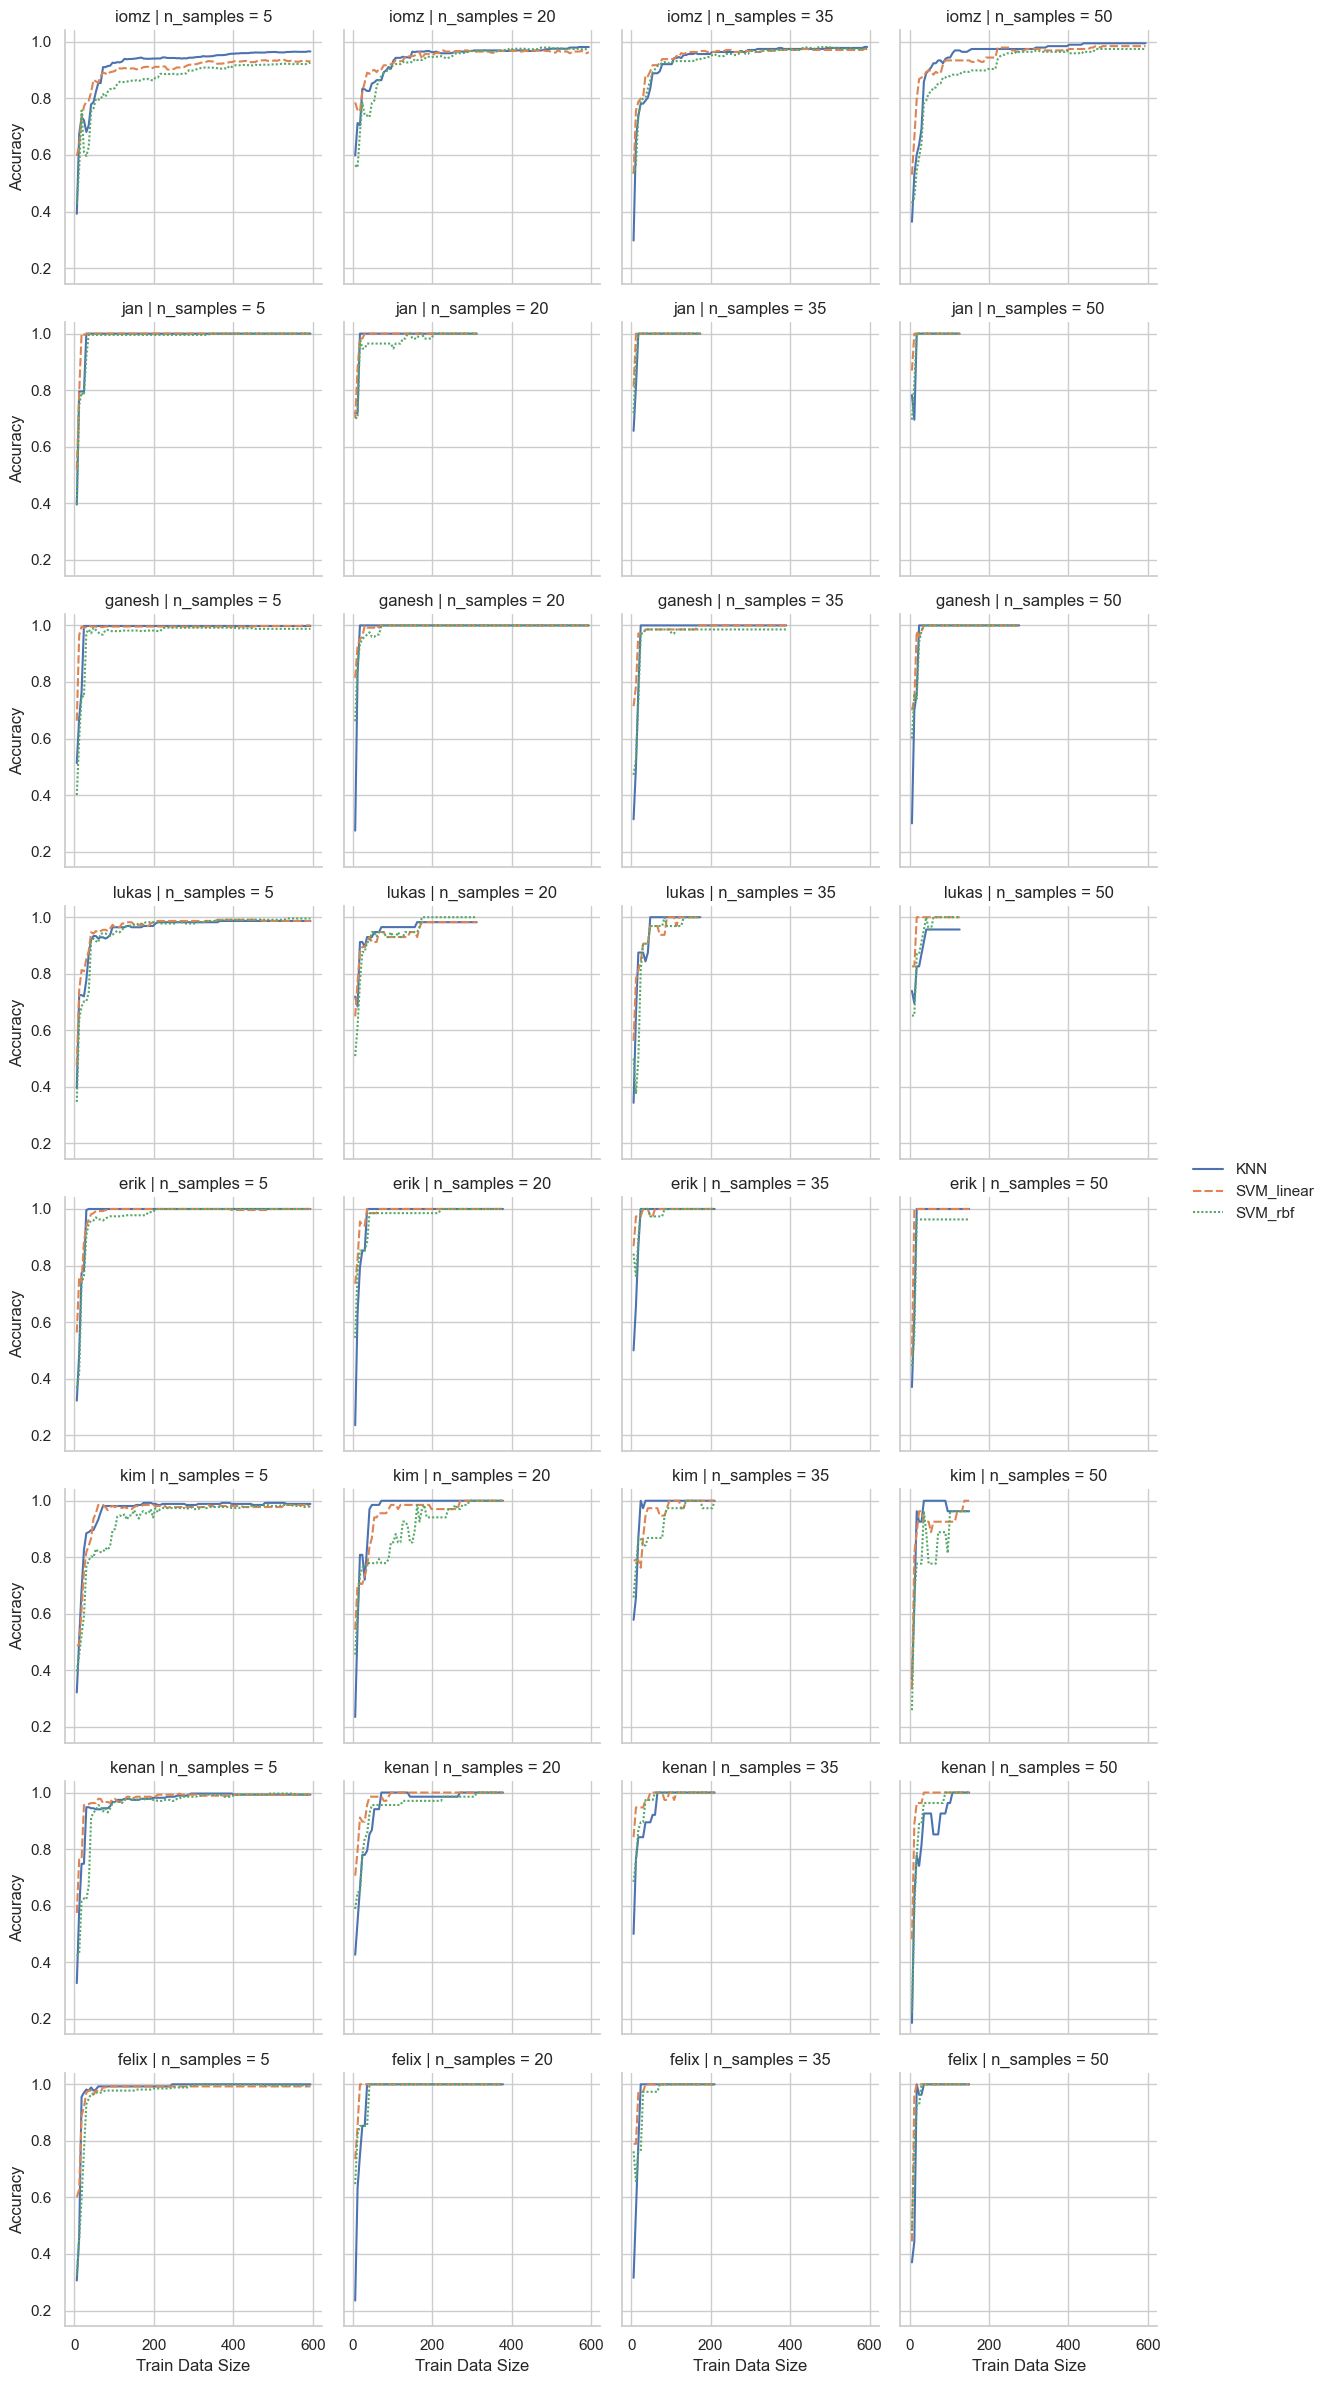

In [16]:
#sns.set_theme(style="ticks")
p = sorted((data_path).glob('eval-*.csv'), reverse=True)[0]
#p = sorted((data_path).glob('n_samples*.csv'), reverse=True)[0]

df = pd.read_csv(p)
df['train_data_size'] = df['train_size'] * df['n_samples']

df = df[df.model != 'SVM_poly']

g = sns.FacetGrid(df, col='n_samples', row='user', height=3)
#g = sns.FacetGrid(df, col='n_samples', height=3, col_wrap=3)
#g = sns.FacetGrid(df, col='n_samples', height=3)
g.map_dataframe(sns.lineplot, x='train_size', y='acc', hue='model', style="model")
g.set_titles(col_template="n_samples = {col_name}", row_template="{row_name}")
g.set_axis_labels("Train Data Size", "Accuracy")
#g.set(xlim=(12, 140))
g.add_legend()
g.tight_layout()
g.savefig("train_size-acc-n_samples.png")

/Users/iomz/.asdf/installs/python/3.10.11/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


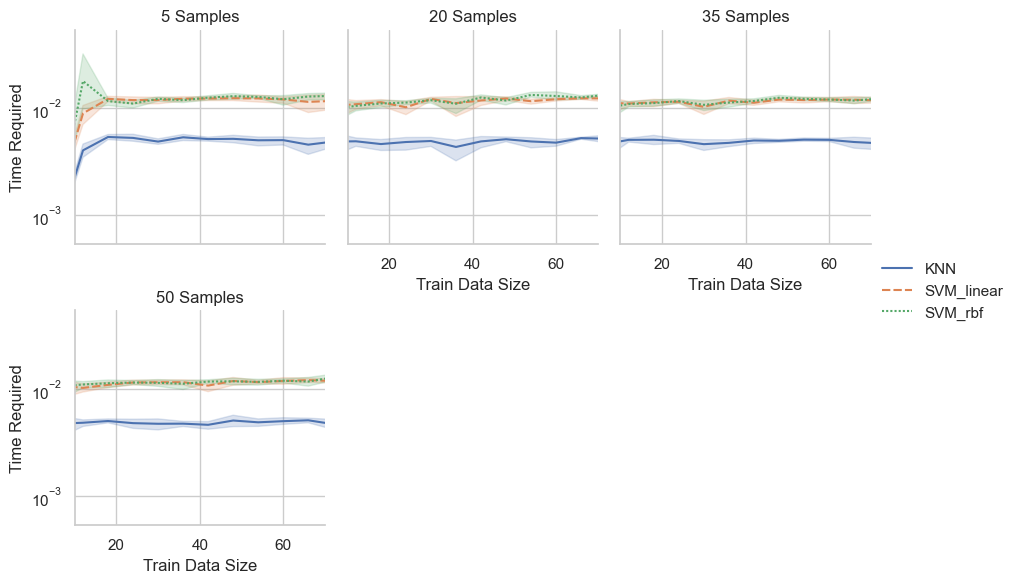

In [17]:
g = sns.FacetGrid(df, col='n_samples', aspect=1.0, col_wrap=3)
g.map_dataframe(sns.lineplot, x='train_size', y='t', hue='model', style="model")
g.set_titles(col_template="{col_name} Samples", row_template="{row_name}")
g.set_axis_labels("Train Data Size", "Time Required")
#g.tight_layout()
g.set(xlim=(10, 70), yscale='log')
g.add_legend()
g.savefig("train_size-time-n_samples.png")